In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['Season'] = df['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Summer',4:'Summer',5:'Summer',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
    10:'Post-Monsoon',11:'Post-Monsoon'
})

# Compute BTEX ratios for the whole dataset first
df['TB_ratio'] = df['Toluene'] / df['Benzene'].replace(0, np.nan)

# Dynamically find which stations ACTUALLY have valid TB_ratio data (at least 50 valid hours)
valid_counts = df[(df['TB_ratio'] > 0) & (df['TB_ratio'] < 20)].groupby('Station')['TB_ratio'].count()

good_voc_stations = valid_counts[valid_counts > 50].index.tolist()
print(f"Dynamically found {len(good_voc_stations)} stations with robust VOC data: {good_voc_stations}")

# Filter the dataset to just these good stations
df_voc = df[df['Station'].isin(good_voc_stations)].copy()

# Remove physically impossible ratios
df_voc = df_voc[(df_voc['TB_ratio'] > 0) & (df_voc['TB_ratio'] < 20)]

print("\nVOC data shape:", df_voc.shape)
print("\nStations with VOC data:")
print(df_voc.groupby('Station')[['Benzene','Toluene','TB_ratio']].describe().round(2))


Dynamically found 29 stations with robust VOC data: ['Alipur', 'Anand_Vihar', 'Ashok_Vihar', 'DTU', 'Dr._Karni_Singh_Shooting_Range', 'Dwarka-Sector_8', 'Jahangirpuri', 'Jawaharlal_Nehru_Stadium', 'Lodhi_Road', 'Major_Dhyan_Chand_National_Stadium', 'Mandir_Marg', 'Mundka', 'NSIT_Dwarka', 'Najafgarh', 'Narela', 'Nehru_Nagar', 'North_Campus_DU', 'Okhla_Phase-2', 'Patparganj', 'Punjabi_Bagh', 'Pusa', 'R_K_Puram', 'Rohini', 'Shadipur', 'Sirifort', 'Sonia_Vihar', 'Sri_Aurobindo_Marg', 'Vivek_Vihar', 'Wazirpur']

VOC data shape: (699595, 32)

Stations with VOC data:
                                    Benzene                                  \
                                      count   mean    std   min   25%   50%   
Station                                                                       
Alipur                              17038.0   1.58   1.63  0.10  0.60  1.10   
Anand_Vihar                         29148.0   4.66   4.60  0.10  1.90  3.20   
Ashok_Vihar                         29

In [9]:
# Summary of ratios per station
ratio_summary = df_voc.groupby('Station').agg(
    Benzene_mean=('Benzene','mean'),
    Toluene_mean=('Toluene','mean'),
    TB_ratio_mean=('TB_ratio','mean'),
    TB_ratio_median=('TB_ratio','median'),
    count=('Benzene','count')
).round(3)

print("=== BTEX RATIO SUMMARY BY STATION ===\n")
print(ratio_summary)

# Interpret source type
print("\n=== SOURCE INTERPRETATION ===")
for station, row in ratio_summary.iterrows():
    tb = row['TB_ratio_median']
    if tb > 2.0:
        source = "🚗 Traffic-dominated"
    elif tb < 1.0:
        source = "🏭 Industrial/solvent-dominated"
    else:
        source = "🏘️ Mixed sources"
    print(f"{station}: T/B = {tb:.2f} → {source}")


=== BTEX RATIO SUMMARY BY STATION ===

                                    Benzene_mean  Toluene_mean  TB_ratio_mean  \
Station                                                                         
Alipur                                     1.577        11.251          6.971   
Anand_Vihar                                4.660        26.894          6.878   
Ashok_Vihar                                5.871        27.614          5.375   
DTU                                       12.193        54.713          4.716   
Dr._Karni_Singh_Shooting_Range             3.807        28.591          7.604   
Dwarka-Sector_8                            4.376        29.527          6.982   
Jahangirpuri                               5.564        33.939          7.811   
Jawaharlal_Nehru_Stadium                   3.716        30.025          9.535   
Lodhi_Road                                 2.006        11.247          6.102   
Major_Dhyan_Chand_National_Stadium         6.021        27.660        

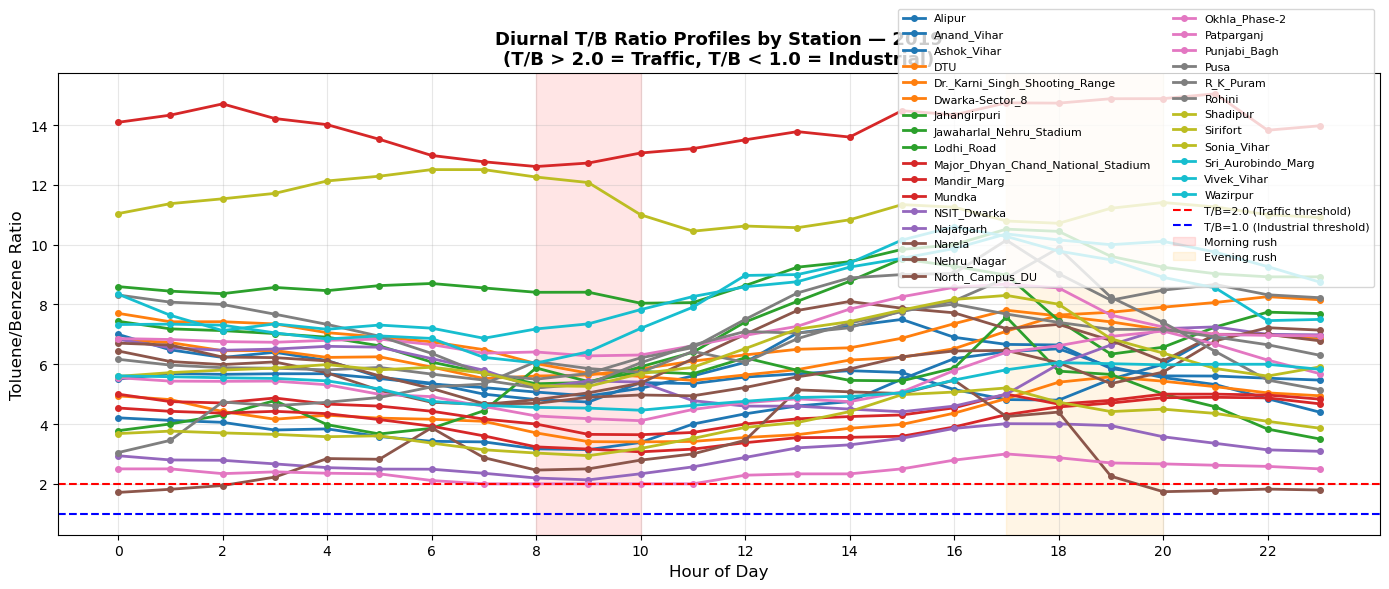

Saved!


In [10]:
diurnal_tb = df_voc.groupby(['Station','Hour'])['TB_ratio'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(good_voc_stations))))

for station, color in zip(good_voc_stations, colors):
    data = diurnal_tb[diurnal_tb['Station']==station]
    if len(data) > 0:
        ax.plot(data['Hour'], data['TB_ratio'], 
               marker='o', markersize=4, linewidth=2,
               label=station, color=color)

ax.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='T/B=2.0 (Traffic threshold)')
ax.axhline(1.0, color='blue', linestyle='--', linewidth=1.5, label='T/B=1.0 (Industrial threshold)')
ax.axvspan(8, 10, alpha=0.1, color='red', label='Morning rush')
ax.axvspan(17, 20, alpha=0.1, color='orange', label='Evening rush')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Toluene/Benzene Ratio', fontsize=12)
ax.set_title('Diurnal T/B Ratio Profiles by Station — 2019\n(T/B > 2.0 = Traffic, T/B < 1.0 = Industrial)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2, bbox_to_anchor=(1.0, 1.15))
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/17_diurnal_TB_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")


=== STATION CLUSTERS BY VOC SOURCE TYPE ===

                                        TB  Benzene        Source_Type
Station                                                               
Alipur                               5.750    1.577   Industrial/Mixed
Anand_Vihar                          5.807    4.660      Low-VOC/Clean
Ashok_Vihar                          4.429    5.871      Low-VOC/Clean
DTU                                  4.258   12.193      Low-VOC/Clean
Dr._Karni_Singh_Shooting_Range       6.900    3.807      Low-VOC/Clean
Dwarka-Sector_8                      6.629    4.376      Low-VOC/Clean
Jahangirpuri                         7.176    5.564      Low-VOC/Clean
Jawaharlal_Nehru_Stadium             8.865    3.716      Low-VOC/Clean
Lodhi_Road                           5.057    2.006   Industrial/Mixed
Major_Dhyan_Chand_National_Stadium   4.029    6.021      Low-VOC/Clean
Mandir_Marg                          4.458    2.664   Industrial/Mixed
Mundka                          

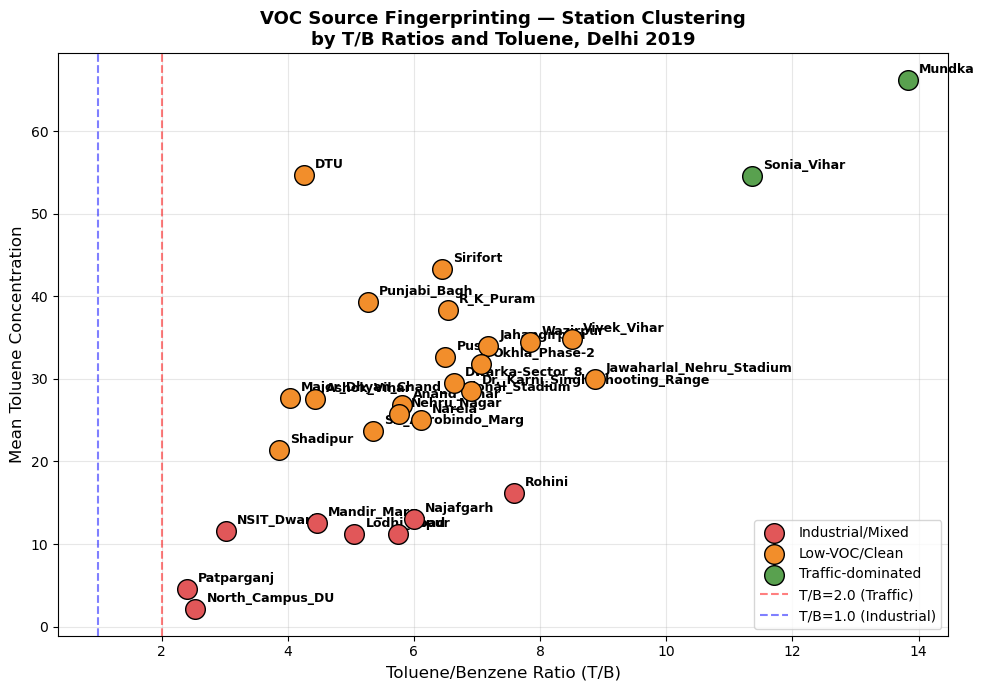

Saved!


In [11]:
# Cluster stations by their VOC fingerprint
station_ratios = df_voc.groupby('Station').agg(
    TB=('TB_ratio','median'),
    Benzene=('Benzene','mean'),
    Toluene=('Toluene','mean')
).dropna()

if len(station_ratios) < 2:
    print(f"Not enough stations to cluster! Only {len(station_ratios)} station(s) found with overlapping VOC data.")
else:
    # Safely assign number of clusters based on how many valid stations we found!
    n_clusters = min(3, len(station_ratios))
    
    # Normalize and cluster
    scaler = StandardScaler()
    X_cluster = scaler.fit_transform(station_ratios[['TB','Benzene','Toluene']])
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    station_ratios['Cluster'] = kmeans.fit_predict(X_cluster)
    
    # Label clusters dynamically
    if n_clusters == 3:
        cluster_labels = {0:'Traffic-dominated', 1:'Industrial/Mixed', 2:'Low-VOC/Clean'}
    else:
        cluster_labels = {i: f"Cluster {i+1}" for i in range(n_clusters)}
        
    station_ratios['Source_Type'] = station_ratios['Cluster'].map(cluster_labels)
    
    print("=== STATION CLUSTERS BY VOC SOURCE TYPE ===\n")
    print(station_ratios[['TB','Benzene','Source_Type']].round(3))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    colors_cluster = ['#e15759', '#f28e2b', '#59a14f']
    unique_stypes = station_ratios['Source_Type'].unique()
    
    for stype, color in zip(unique_stypes, colors_cluster):
        subset = station_ratios[station_ratios['Source_Type']==stype]
        ax.scatter(subset['TB'], subset['Toluene'], 
                  c=color, s=200, label=stype, zorder=5, edgecolors='black')
        for idx, row in subset.iterrows():
            ax.annotate(idx, (row['TB'], row['Toluene']), 
                       fontsize=9, fontweight='bold',
                       xytext=(8, 5), textcoords='offset points')
    
    ax.axvline(2.0, color='red', linestyle='--', alpha=0.5, label='T/B=2.0 (Traffic)')
    ax.axvline(1.0, color='blue', linestyle='--', alpha=0.5, label='T/B=1.0 (Industrial)')
    ax.set_xlabel('Toluene/Benzene Ratio (T/B)', fontsize=12)
    ax.set_ylabel('Mean Toluene Concentration', fontsize=12)
    ax.set_title('VOC Source Fingerprinting — Station Clustering\nby T/B Ratios and Toluene, Delhi 2019',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/18_voc_station_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved!")
